Section 1

David is a 22-year-old student at San Jose State University who frequently uses Apple Pay and credit cards for small daily purchases such as coffee, food, transportation, and online shopping. Although he believes his spending is reasonable, he often runs out of money by the end of the month and does not clearly understand where his money goes. This project focuses on college students in San Jose who have access to banking data but lack meaningful interpretation and behavioral guidance. The failure point is not the lack of financial data, but the lack of clear insight that connects daily transactions to long-term spending habits. Since Milestone 1, the project changed from only tracking transactions to combining structured spending extraction with visual recognition, because real financial habits often come from both transaction records and everyday behavior. This project connects to SDG 10 Reduced Inequalities by helping students with limited financial experience make more informed financial decisions.

Section 2

Input → The system receives student transaction descriptions such as “Starbucks $6,” “Uber $15,” or “Amazon $40,” plus optional images related to daily spending such as coffee, food, or shopping environments.
AI Processing → Lab 2 structured data extraction categorizes transactions, calculates total spending, identifies the largest expense, and assigns a spending level. Lab 3 visual recognition analyzes images to connect real-world behaviors, such as buying coffee, to possible spending habits.
Output → The system produces categorized spending summaries, spending-level labels, behavioral insights, and personalized recommendations.
Real-world Action → The student reviews the AI feedback, becomes more aware of repeated small purchases, adjusts spending behavior, and makes better budgeting decisions.

Section 3 Lab 2

Lab 2 supports this project because it shows how unstructured student spending descriptions can be transformed into structured financial data. The AI extracts fields such as total spent, main category, largest expense, spending level, and behavioral guidance. This demonstrates how the proposed system can turn raw transaction-like text into organized information that students can actually understand. However, the output also shows a limitation: the AI may classify the same spending pattern differently across runs, such as labeling the main category as “Shopping” in one run and “Clothing” in another. This matters because inconsistent categories can lead to misleading budgeting advice.

Section 3 Lab 3

Lab 3 supports this project by showing how visual recognition can connect real-world objects to financial behavior. In the image analysis, the AI identified coffee and a dollar sign, then connected the image to the cost of coffee and daily spending habits. This helps the system go beyond transaction data by recognizing everyday behaviors that may contribute to poor spending habits. However, the output also shows a limitation: the AI sometimes gives broad or symbolic explanations instead of directly focusing on the student’s personal financial behavior. This means visual AI should support the system, but it should not replace structured spending analysis.




# Setting Up Your Development Environment
- Install the Google Generative AI Python library.

In [ ]:
!pip install -q google-generativeai

# Importing and Initializing Gemini

Store your API key in Colab Secrets:
 1. Click the key icon in the left sidebar
 2. Add a secret named `GEMINI_API_KEY`
 3. Paste your API key as the value
 4. Toggle "Notebook access" to ON

Get your free API key at: https://aistudio.google.com

> **Note:** You may see a warning that `google.generativeai` is deprecated. This is expected — the code still works correctly. Ignore the warning and continue.

In [ ]:
import google.generativeai as genai
from google.colab import userdata, files
from IPython.display import display
from PIL import Image as PILImage
import time
import os
import json

genai.configure(api_key=userdata.get('GEMINI_API_KEY'))
print("Gemini initialized successfully.")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Gemini initialized successfully.


# Part 1: The Problem — Inconsistent Output

A student describes daily spending in a casual message:

"Today I bought coffee for $6, lunch for $15, an Uber ride for $18, and a hoodie for $45. I feel like I did not spend much, but my money disappears fast."

Ask the model to extract the key spending information without using a schema.

Run the cell a few times and notice how the format may change each time.
A budgeting system cannot reliably analyze output if the format looks different on every run.

In [ ]:
student_spending_message = (
    "Today I bought coffee for $6, lunch for $15, an Uber ride for $18, "
    "and a hoodie for $45. I feel like I did not spend much, but my money disappears fast."
)

def extract_unstructured(message):
    m = genai.GenerativeModel(
        model_name="gemini-2.5-flash",
        system_instruction="Extract the student's spending information from this message."
    )
    response = m.generate_content(message)
    time.sleep(12)
    return response.text

print("--- Student spending message ---")
print(student_spending_message)

print("\n--- Unstructured extraction run 3 times, notice the format may change ---")

print("\nRun 1:")
print(extract_unstructured(student_spending_message))

print("\nRun 2:")
print(extract_unstructured(student_spending_message))

print("\nRun 3:")
print(extract_unstructured(student_spending_message))

--- Student spending message ---
Today I bought coffee for $6, lunch for $15, an Uber ride for $18, and a hoodie for $45. I feel like I did not spend much, but my money disappears fast.

--- Unstructured extraction run 3 times, notice the format may change ---

Run 1:
Here's your spending information for today:

*   **Coffee:** $6
*   **Lunch:** $15
*   **Uber ride:** $18
*   **Hoodie:** $45

**Total spent today: $84**

Run 2:
Here is the student's spending information for today:

*   **Coffee:** $6
*   **Lunch:** $15
*   **Uber ride:** $18
*   **Hoodie:** $45

**Total spent today:** $84

Run 3:
Here is your spending information for today:

*   **Coffee:** $6
*   **Lunch:** $15
*   **Uber ride:** $18
*   **Hoodie:** $45

**Total spent today: $84**


Part 2: Define a Schema

A schema is the structure we give the AI to organize student spending information.

We define five fields — total_spent, main_category, largest_expense, spending_level, and behavioral_guidance — and tell the AI exactly what type each field should be.

The AI cannot return anything outside this structure.

Notice the two important behavioral fields compared to a simple expense tracker:

spending_level — estimates whether the student’s spending is LOW, MEDIUM, or HIGH

behavioral_guidance — provides personalized financial advice based on the spending pattern

This structure helps transform raw spending descriptions into organized financial insights that students can understand and act on.

In [ ]:
# The schema — the form the AI must fill in exactly.
schema_prompt = """

Extract information from this student spending message.

Return ONLY valid JSON with exactly these five fields:

{
  "total_spent": number,
  "main_category": string,
  "largest_expense": string,
  "spending_level": "LOW" or "MEDIUM" or "HIGH",
  "behavioral_guidance": string
}

Spending level guide:
LOW = under $20 total spending
MEDIUM = $20 to $60 total spending
HIGH = over $60 total spending

No explanation. No markdown. JSON only.

"""

print("Schema defined. The AI must return exactly these five fields:")
for field in ["total_spent", "main_category", "largest_expense", "spending_level", "behavioral_guidance"]:
    print(f"  - {field}")

Schema defined. The AI must return exactly these five fields:
  - total_spent
  - main_category
  - largest_expense
  - spending_level
  - behavioral_guidance


# Part 3: Extract with the Schema

Now use the schema as the system instruction — the key change from Part 1.

Run it three times on the same message. The format will be identical every time.

That consistency makes the output reliable for analyzing student spending behavior and generating budgeting insights.

In [ ]:
def extract_structured(message):
    m = genai.GenerativeModel(
        model_name="gemini-2.5-flash",
        system_instruction=schema_prompt
    )

    response = m.generate_content(message)
    time.sleep(12)

    raw = response.text.strip()

    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0].strip()

    return json.loads(raw)

print("--- Student spending message ---")
print(student_spending_message)

print("\n--- Structured extraction run 3 times, format should be identical each time ---")

for i in range(1, 4):
    print(f"\nRun {i}:")
    result = extract_structured(student_spending_message)
    print(json.dumps(result, indent=2, ensure_ascii=False))

--- Student spending message ---
Today I bought coffee for $6, lunch for $15, an Uber ride for $18, and a hoodie for $45. I feel like I did not spend much, but my money disappears fast.

--- Structured extraction run 3 times, format should be identical each time ---

Run 1:
{
  "total_spent": 84,
  "main_category": "Shopping",
  "largest_expense": "hoodie",
  "spending_level": "HIGH",
  "behavioral_guidance": "Your spending today was high. Large purchases like the hoodie can significantly impact your budget, even if you don't feel like you spent much. Consider tracking your expenses daily to get a clearer picture of where your money is going."
}

Run 2:
{
  "total_spent": 84,
  "main_category": "Clothing",
  "largest_expense": "Hoodie",
  "spending_level": "HIGH",
  "behavioral_guidance": "Your total spending today was high, mainly driven by a single large purchase. Being mindful of these bigger impulse buys can help you manage your money more effectively."
}

Run 3:
{
  "total_spent":

Part 4: Test Three Different Spending Behaviors

Real financial behavior varies across different spending situations.

Here are three examples that represent low, medium, and high student spending patterns.

Run the cell and observe:

Does the AI correctly identify the spending level?

Does the AI provide reasonable behavioral guidance?

Where does the AI seem confident, and where does it seem inconsistent?

Pay attention to how the AI categorizes spending behavior differently across examples.

In [ ]:
test_messages = [
    {
        "label": "Low Spending",
        "message": "I bought a coffee for $6 and a snack for $4 today."
    },
    {
        "label": "Medium Spending",
        "message": "Today I spent $14 on lunch, $18 on Uber, and $12 on boba."
    },
    {
        "label": "High Spending",
        "message": "I spent $25 on lunch, $38 on Uber, $45 on clothes, and $12 on coffee. I thought it was small spending, but it added up quickly."
    }
]

for item in test_messages:
    print(f"=== {item['label']} ===")
    print(f"Input: {item['message']}")
    result = extract_structured(item["message"])
    print("Output:")
    print(json.dumps(result, indent=2, ensure_ascii=False))
    print()

=== Low Spending ===
Input: I bought a coffee for $6 and a snack for $4 today.
Output:
{
  "total_spent": 10,
  "main_category": "Food & Drinks",
  "largest_expense": "coffee",
  "spending_level": "LOW",
  "behavioral_guidance": "Good job keeping your spending low today!"
}

=== Medium Spending ===
Input: Today I spent $14 on lunch, $18 on Uber, and $12 on boba.
Output:
{
  "total_spent": 44,
  "main_category": "Food & Drink",
  "largest_expense": "Uber",
  "spending_level": "MEDIUM",
  "behavioral_guidance": "Your spending is at a medium level. Consider tracking your food and transport expenses."
}

=== High Spending ===
Input: I spent $25 on lunch, $38 on Uber, $45 on clothes, and $12 on coffee. I thought it was small spending, but it added up quickly.
Output:
{
  "total_spent": 120,
  "main_category": "Shopping",
  "largest_expense": "clothes",
  "spending_level": "HIGH",
  "behavioral_guidance": "Your spending is high. Be mindful of how individual purchases accumulate; consider tra

Part 5: Spending Behavior Image Analysis

You need an image to analyze. Choose one image related to student spending behavior.

Examples:
- A coffee drink
- A food receipt
- A shopping bag
- A credit card or Apple Pay screen
- A transportation receipt
- A daily purchase environment

The goal is to see whether visual recognition can connect everyday objects to possible spending habits.

Supported formats: jpg, jpeg, png, gif, webp — maximum 20 MB.

This image analysis supports the project because students often do not notice how small daily purchases become repeated financial habits.

Saving coffeemoney.jpg to coffeemoney.jpg
Uploaded: coffeemoney.jpg
Image size: 612x408 pixels


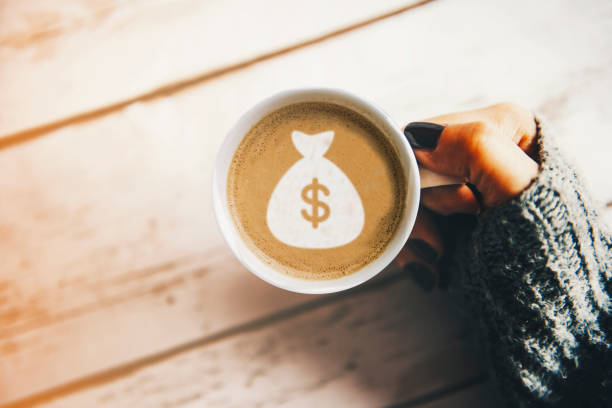

In [ ]:
# Upload your image from your computer.
uploaded = files.upload()

# Get the filename of the uploaded file.
image_filename = list(uploaded.keys())[0]

# Display the uploaded image so you can see what the model will analyze.
img = PILImage.open(image_filename)
print(f"Uploaded: {image_filename}")
print(f"Image size: {img.size[0]}x{img.size[1]} pixels")
display(img)

# Part 2: Core Analysis Function

This function sends both the image and a question to Gemini.
This is called **multimodal input** — the model processes image and text together.

Run this cell to define the function. No output yet — that comes in Part 3.

In [ ]:
def analyze_image(image_path, question):
    """
    Send an image + a question to Gemini and return the response.
    Returns: (response_text, usage_metadata)
    """
    m = genai.GenerativeModel(model_name="gemini-2.5-flash")
    img = PILImage.open(image_path)
    response = m.generate_content([question, img])
    time.sleep(12)  # stays under free tier rate limit
    return response.text, response.usage_metadata

print("analyze_image() function defined. Ready to use in Parts 3 and 4.")

analyze_image() function defined. Ready to use in Parts 3 and 4.


Spending Behavior Image Analysis

The AI analyzes images related to student spending behavior using four financial analysis questions.

The system looks for:

What spending-related objects or symbols are visible?

What financial behaviors might the image represent?

What spending risks or habits could be connected to the image?

What budgeting recommendation should be given to the student?

Run the cell below to see how Gemini analyzes the image from a financial behavior perspective.

This may take up to two minutes due to rate limits — that is expected.

In [ ]:
spending_image_questions = [

    ("OBJECTS", "What spending-related objects or symbols are visible in this image?"),

    ("BEHAVIOR", "How could the objects in this image connect to student spending behavior?"),

    ("RISK", "What financial habit risk could this image represent for a college student?"),

    ("ACTION", "What practical budgeting recommendation should be given based on this image?")

]

image_results = {"answers": {}, "total_tokens": 0}

for label, question in spending_image_questions:

    print(f"--- {label} ---")

    answer, usage = analyze_image(image_filename, question)

    image_results["answers"][label] = answer

    image_results["total_tokens"] += usage.total_token_count

    print(answer)

    print()

print(f"--- Total tokens used: {image_results['total_tokens']} ---")

print("Running on Gemini free tier — no cost.")

--- OBJECTS ---
The spending-related objects or symbols visible in this image are:

1.  A **money bag** symbol (depicted in the latte art).
2.  A **dollar sign ($)** symbol (also depicted within the money bag on the latte art).

--- BEHAVIOR ---
The objects in this image offer several powerful connections to student spending behavior:

1.  **The "Latte Factor" / Daily Discretionary Spending:**
    *   **The Coffee:** Represents a common daily "luxury" or habit for many students. Coffee, especially from cafes, is a recurring expense that, individually, seems small.
    *   **The Money Bag Icon:** Directly superimposed on the coffee, this symbolizes the financial cost associated with this habit.
    *   **Connection:** The image perfectly illustrates the "latte factor" – how small, regular purchases like a daily coffee can add up significantly over time and impact a student's overall budget. Students might not realize how much they spend on coffee (or similar items like snacks, fast food

Section 4 — Edge Case Elicitation

Prompt used:

“I spent $28 at Target, $35 on Amazon, $12 at Starbucks, and $18 on Uber. The Target purchase included groceries, school supplies, and a phone charger. The Amazon purchase included both a textbook and a hoodie. I am not sure which category these should go into.”

This prompt was designed to surface a failure because stores like Target and Amazon contain mixed-category purchases. The system may force the spending into one main category even though the real spending includes food, school, transportation, and shopping.

Assessment:

Near-miss — the AI correctly calculated total spending, but the category classification may still be misleading because mixed purchases were simplified into one category. This could lead the student to receive incorrect budgeting advice and misunderstand which spending behavior is actually causing financial problems.

In [ ]:
edge_case_message = (
    "I spent $28 at Target, $35 on Amazon, $12 at Starbucks, and $18 on Uber. "
    "The Target purchase included groceries, school supplies, and a phone charger. "
    "The Amazon purchase included both a textbook and a hoodie. "
    "I am not sure which category these should go into."
)

print("--- Edge Case Input ---")
print(edge_case_message)

print("\n--- Edge Case Output ---")
edge_case_result = extract_structured(edge_case_message)
print(json.dumps(edge_case_result, indent=2, ensure_ascii=False))

--- Edge Case Input ---
I spent $28 at Target, $35 on Amazon, $12 at Starbucks, and $18 on Uber. The Target purchase included groceries, school supplies, and a phone charger. The Amazon purchase included both a textbook and a hoodie. I am not sure which category these should go into.

--- Edge Case Output ---
{
  "total_spent": 93,
  "main_category": "Student Essentials",
  "largest_expense": "Amazon",
  "spending_level": "HIGH",
  "behavioral_guidance": "Your spending is high this period. Review your purchases to identify areas where you might save, especially on non-essential items or by finding cheaper alternatives for necessities."
}


# Part 6: Ask Your Own Financial Behavior Question

Now that you have seen the standard financial behavior analysis, ask the model a question related to your image or your project scenario.

Examples:

- "How could repeated coffee purchases affect a college student's monthly budget?"

- "What emotional spending behavior might this image represent?"

- "How can small daily purchases become long-term financial problems?"

- "What budgeting strategy would help reduce this type of spending?"

- "What financial habits could develop from repeated purchases like this?"

In [ ]:
custom_question = input("\nAsk your own question about the image: ")
custom_result, custom_usage = analyze_image(image_filename, custom_question)

print("\n--- Response ---")
print(custom_result)
print(f"\nTokens used: {custom_usage.total_token_count}")


Ask your own question about the image: How does spending money on things like coffee contribute to developing poor spending habits?

--- Response ---
Spending money on small, seemingly insignificant items like a daily coffee can contribute to developing poor spending habits through several mechanisms, even though a single coffee isn't going to break the bank. It's the *pattern* and the *mindset* behind it that are problematic.

Here's how:

1.  **The "Latte Factor" (Cumulative Effect):** This is the most classic example. While $5 for a coffee might seem trivial, it adds up quickly.
    *   $5/day x 5 days/week = $25/week
    *   $25/week x 4 weeks/month = $100/month
    *   $100/month x 12 months/year = $1,200/year
    This annual sum could be used for significant savings, debt repayment, investments, or a larger, more impactful purchase (like a vacation, a down payment contribution, or a new appliance). The habit makes you accustomed to seeing this money disappear without realizing i